In [13]:
#First we imported the data into my SQL Workbench and then Using the following queries we have
#Done some feature engineering based on disriptive analytics and exported the data in csv
'''
SELECT
    o.customer_id,
    COUNT(DISTINCT o.order_id)                        AS frequency,
    SUM(op.payment_value)                             AS monetary,
    MAX(o.order_purchase_timestamp)                   AS last_purchase,
    AVG(op.payment_installments)                      AS avg_installments,
    AVG(oi.freight_value)                             AS avg_freight,
    COUNT(DISTINCT oi.product_id)                     AS unique_products,
    c.customer_state
FROM orders o
LEFT JOIN order_payments op  ON o.order_id   = op.order_id
LEFT JOIN order_items oi     ON o.order_id   = oi.order_id
LEFT JOIN customers c        ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY o.customer_id, c.customer_state
INTO OUTFILE 'C:/ProgramData/MySQL/MySQL Server 8.0/Uploads/customer_segments.csv'
FIELDS TERMINATED BY ','
ENCLOSED BY '"'
LINES TERMINATED BY '\n';
'''

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv(r'customer_segments.csv',header=None,
                 names=['customer_id','frequency','monetary','last_purchase', 'avg_installments','avg_freight','unique_products','customer_state'],
                 low_memory=False)

In [19]:
df.head(1)

,customer_id,frequency,monetary,last_purchase,avg_installments,avg_freight,unique_products,customer_state
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,2017-11-14 16:08:26,8.0000,24.94,1,SP


In [20]:
#Below we are Cleaning, Handaling and exploring data

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       96478 non-null  str  
 1   frequency         96478 non-null  int64
 2   monetary          96478 non-null  str  
 3   last_purchase     96478 non-null  str  
 4   avg_installments  96478 non-null  str  
 5   avg_freight       96478 non-null  str  
 6   unique_products   96478 non-null  int64
 7   customer_state    96478 non-null  str  
dtypes: int64(2), str(6)
memory usage: 12.3 MB


In [22]:
df['last_purchase'] = pd.to_datetime(df['last_purchase'], errors='coerce')

In [23]:
snapshot_date = df['last_purchase'].max()
df['recency'] = (snapshot_date - df['last_purchase']).dt.days

In [24]:
for col in ['frequency','monetary','avg_installments','avg_freight','unique_products']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [25]:
df.isnull().sum()

customer_id            0
frequency              0
monetary               1
last_purchase          0
avg_installments       1
avg_freight         1333
unique_products        0
customer_state         0
recency                0
dtype: int64

In [35]:
#Removing unnecessary columns
df = df.dropna(subset=['recency','frequency','monetary'])

In [36]:
df[df['avg_freight'].isna()]

,customer_id,frequency,monetary,last_purchase,avg_installments,avg_freight,unique_products,customer_state,recency
83,003a75d228dc67cb2918e40c2aacc4bf,1,79.28,2017-10-19 12:07:22,1.0,NaN,0,PR,314
226,0099bfdae84652b1df38e27c0fc216e3,1,165.80,2018-01-22 20:21:44,3.0,NaN,0,PR,218
251,00af1761df71da362764c51bb96f5118,1,137.60,2017-11-28 18:00:54,2.0,NaN,0,DF,273
276,00bb27539e10159490e73842a90b173e,1,31.58,2017-07-27 14:33:06,1.0,NaN,0,SP,398
387,010e2bfece4b4e44fb7a6aa9c2b2b9d0,1,27.78,2017-12-13 16:58:37,1.0,NaN,0,SP,258
...,...,...,...,...,...,...,...,...,...
96294,ff88c3fe67d72e79283259628c0731e1,1,172.65,2018-01-18 13:37:27,1.0,NaN,0,SP,223
96317,ff96b3b15e8f7a878bede85345e33f0c,1,86.20,2017-08-03 11:13:41,1.0,NaN,0,RS,391
96344,ffa78a5bd171f26facc78c0409e86d3f,1,56.40,2017-11-03 16:19:56,1.0,NaN,0,SC,298
96387,ffbd6fd1ff815c8392bb0f6e2fdeef75,1,106.35,2018-01-05 10:01:43,1.0,NaN,0,BA,236


In [37]:
#replaced null values with 0 because for short period new users had free delivery on first purchase
df['avg_freight'] = df['avg_freight'].fillna(0)

In [38]:
df.isnull().sum()

customer_id         0
frequency           0
monetary            0
last_purchase       0
avg_installments    0
avg_freight         0
unique_products     0
customer_state      0
recency             0
dtype: int64

In [39]:
df.describe()

,frequency,monetary,last_purchase,avg_installments,avg_freight,unique_products,recency
count,96477.0,96477.000000,96477,96477.000000,96477.000000,96477.000000,96477.000000
mean,1.0,204.475005,2018-01-01 23:36:35.953657,2.912138,19.905011,1.024006,239.116453
min,1.0,9.590000,2016-10-03 09:44:50,0.000000,0.000000,0.000000,0.000000
25%,1.0,62.650000,2017-09-14 09:09:57,1.000000,13.080000,1.000000,115.000000
50%,1.0,109.410000,2018-01-20 19:46:23,2.000000,16.290000,1.000000,220.000000
75%,1.0,195.120000,2018-05-05 18:56:01,4.000000,21.150000,1.000000,349.000000
max,1.0,109312.640000,2018-08-29 15:00:37,24.000000,409.680000,8.000000,695.000000
std,0.0,618.966992,NaN,2.697238,15.791082,0.256238,152.830149


In [40]:
df.describe(include='str')

,customer_id,customer_state
count,96477,96477
unique,96477,27
top,00012a2ce6f8dcda20d059ce98491703,SP
freq,1,40500


In [41]:
features = ['recency','frequency','monetary','avg_installments','avg_freight','unique_products']

In [42]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

Train size: 86829 | Test size: 9648


In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[features])
X_test_scaled  = scaler.transform(test_df[features])

In [44]:
# Using Elbow and Shilhoute method to find best K between range 2-8
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
inertia    = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

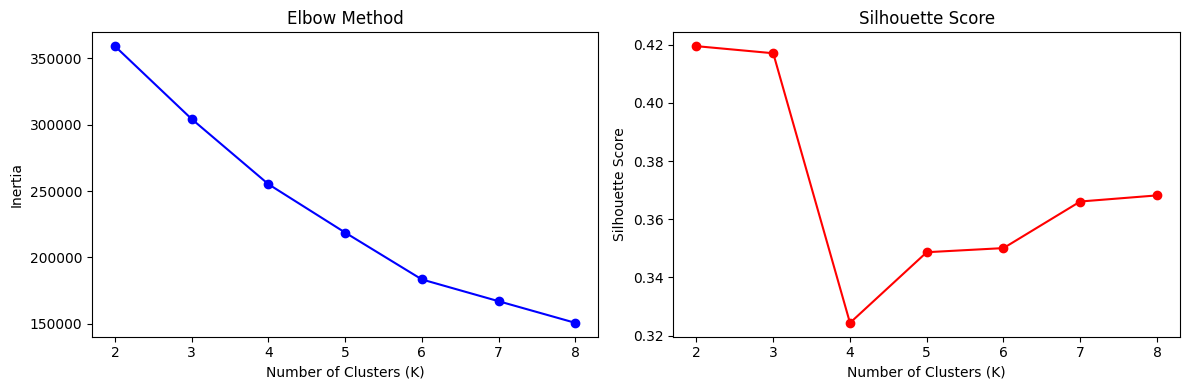

In [45]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

In [49]:
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_df = train_df.copy()
train_df['cluster'] = km_final.fit_predict(X_train_scaled)
# Cluster profiles
profile = train_df.groupby('cluster')[features].mean().round(2)
print("\nCluster Profiles:")
profile


Cluster Profiles:


,recency,frequency,monetary,avg_installments,avg_freight,unique_products
cluster,,,,,,
0,248.86,1.0,383.79,7.25,32.56,0.99
1,236.82,1.0,134.39,1.80,16.88,0.98
2,237.28,1.0,816.90,4.05,18.38,2.16


In [50]:
cluster_labels = {
    0: 'Installment Buyers',   # highest avg_installments (7.25)
    1: 'Low-Value Casual',     # lowest monetary ($134)
    2: 'High-Value Shoppers'   # highest monetary ($816) + most unique products
}
train_df['segment'] = train_df['cluster'].map(cluster_labels)
print("\nSegment Distribution (train):")
print(train_df['segment'].value_counts())
print(train_df['segment'].value_counts(normalize=True).mul(100).round(1))



Segment Distribution (train):
segment
Low-Value Casual       67469
Installment Buyers     16509
High-Value Shoppers     2851
Name: count, dtype: int64
segment
Low-Value Casual       77.7
Installment Buyers     19.0
High-Value Shoppers     3.3
Name: proportion, dtype: float64


In [51]:
#From Here Only write code about Descision tree

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train = train_df[features]
y_train = train_df['cluster']

X_test = test_df[features]
y_test = km_final.predict(X_test_scaled)

scaler_dt = StandardScaler()
X_train_scaled = scaler_dt.fit_transform(X_train)
X_test_scaled_dt = scaler_dt.transform(X_test)

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [53]:
y_pred = dt.predict(X_test_scaled)

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

segment_names = ['Installment Buyers', 'Low-Value Casual', 'High-Value Shoppers']

print("=" * 55)
print("   DECISION TREE EVALUATION ON UNSEEN 10%")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=segment_names))

   DECISION TREE EVALUATION ON UNSEEN 10%
                     precision    recall  f1-score   support

 Installment Buyers       0.98      0.99      0.99      1837
   Low-Value Casual       1.00      0.99      1.00      7505
High-Value Shoppers       0.98      1.00      0.99       306

           accuracy                           0.99      9648
          macro avg       0.99      0.99      0.99      9648
       weighted avg       0.99      0.99      0.99      9648



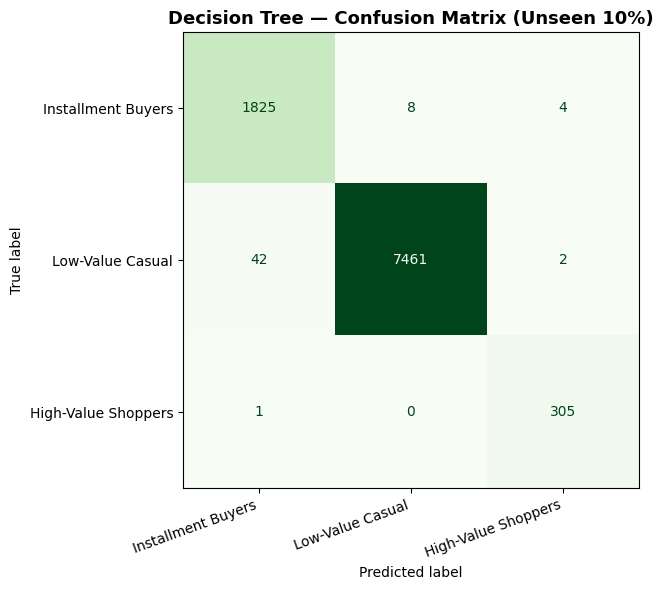

In [55]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=segment_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Decision Tree — Confusion Matrix (Unseen 10%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150)
plt.show()

In [56]:
feat_importance = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
print("Feature Importance:")
print(feat_importance)

Feature Importance:
unique_products     0.500844
avg_installments    0.388042
avg_freight         0.098689
monetary            0.010595
recency             0.001829
frequency           0.000000
dtype: float64


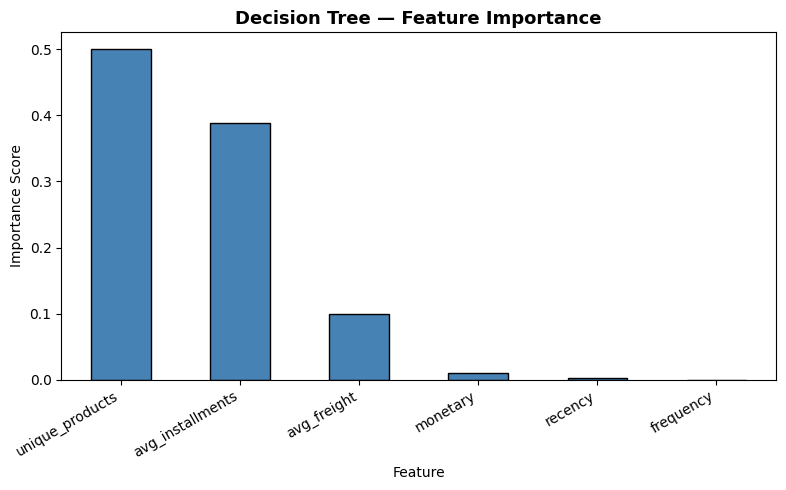

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
feat_importance.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Decision Tree — Feature Importance', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xlabel('Feature')
ax.set_xticklabels(feat_importance.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150)
plt.show()

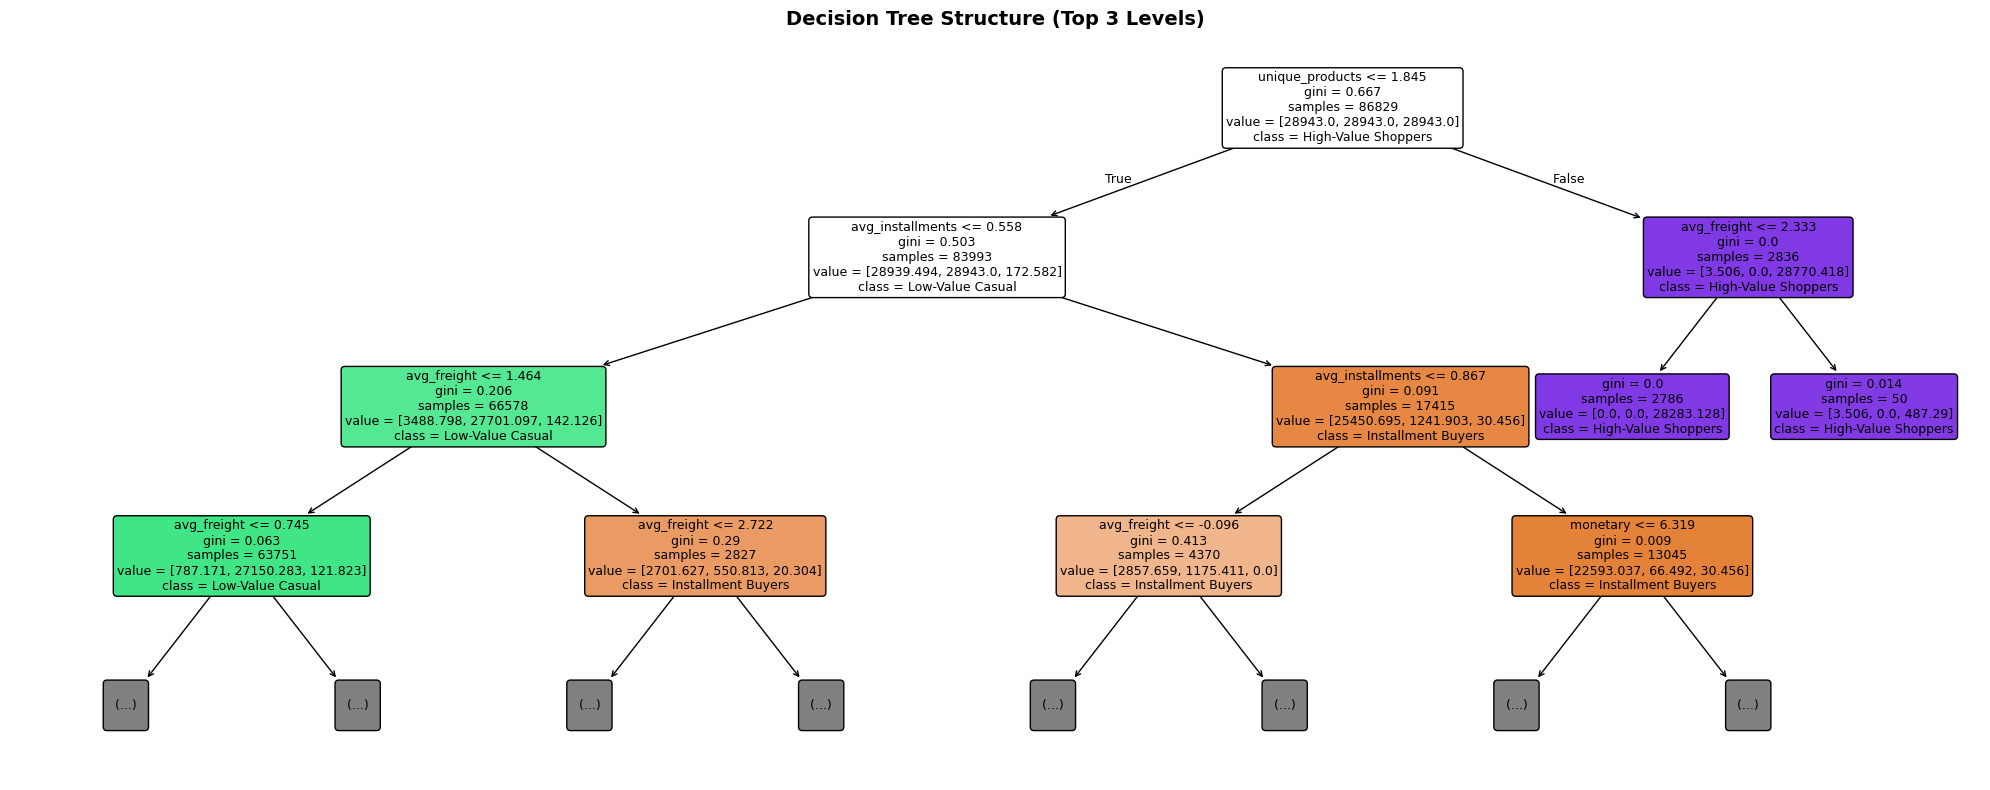

In [58]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=features,
    class_names=segment_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree_structure.png', dpi=150)
plt.show()

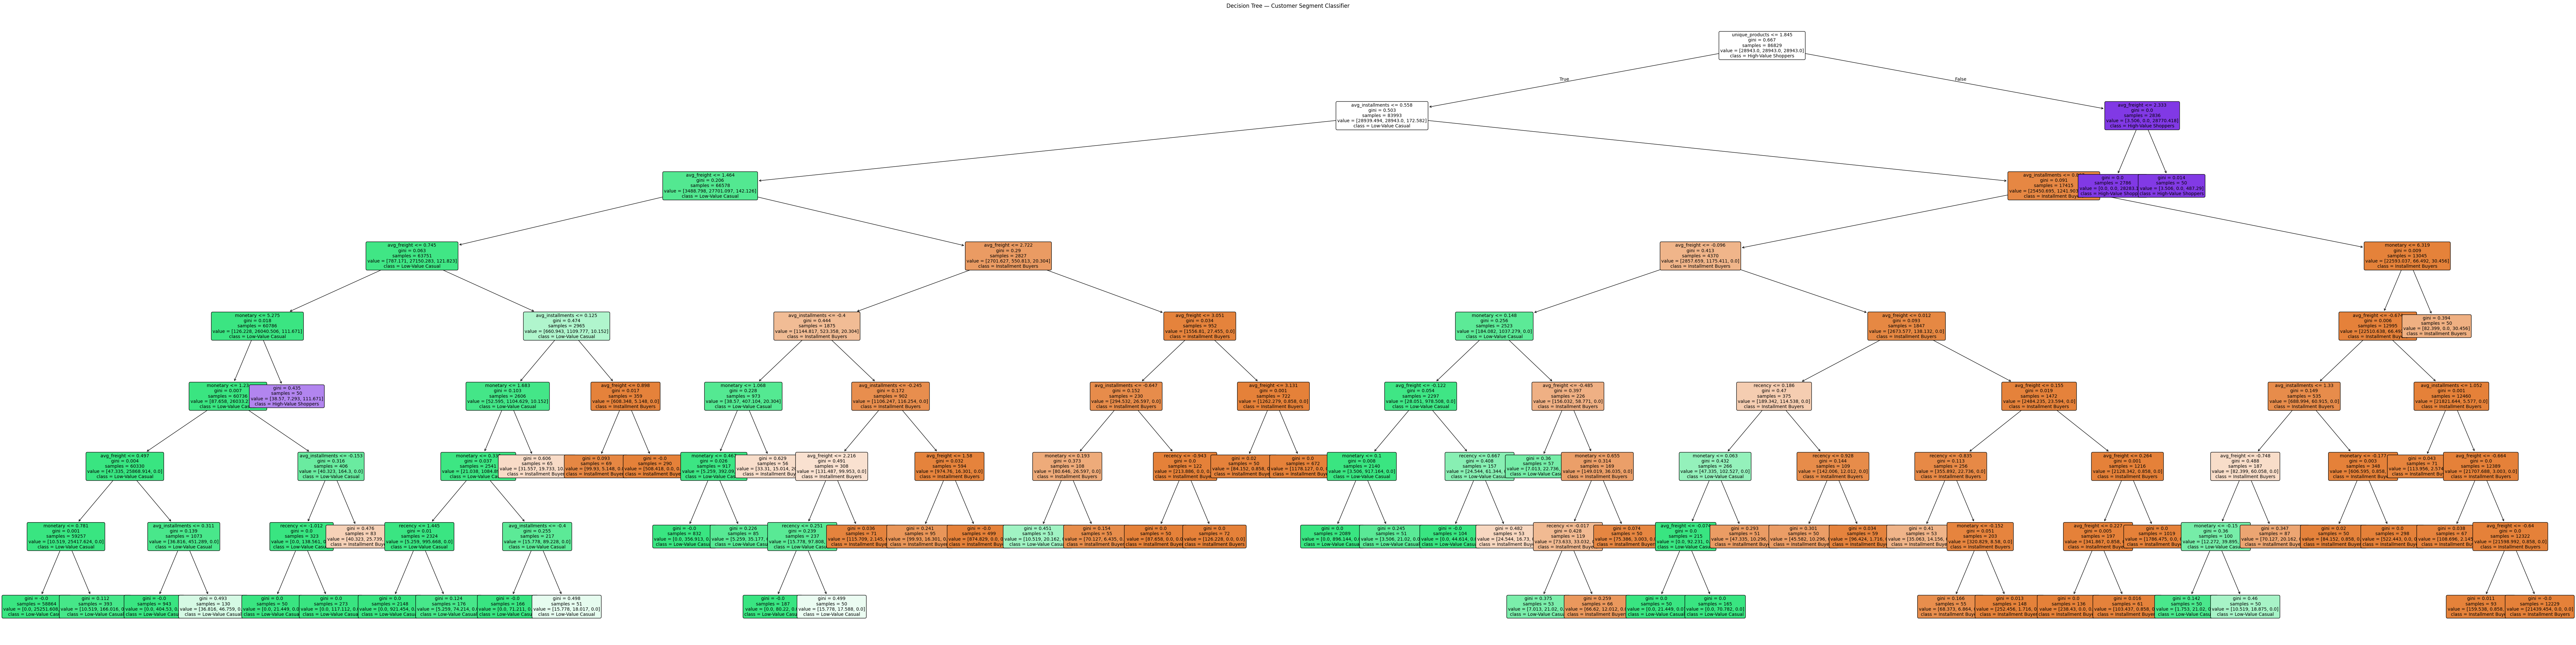

In [59]:
plt.figure(figsize=(80, 20))
plot_tree(
    dt,
    feature_names=features,
    class_names=['Installment Buyers', 'Low-Value Casual', 'High-Value Shoppers'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree — Customer Segment Classifier')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300)
plt.show()

In [60]:
'''
----------------------------------------------------------------------------
----------------------------------------------------------------------------
----------------------------------------------------------------------------
Below are all the experimental codes merged from different jupyter files
The bleow code show the instance of the problems encountered and the above code is the solution
the code below for decision tree is underfitted and there was data leakage if
we dont split the data during clustering process.
----------------------------------------------------------------------------
----------------------------------------------------------------------------
----------------------------------------------------------------------------
'''

'\n----------------------------------------------------------------------------\n----------------------------------------------------------------------------\n----------------------------------------------------------------------------\nBelow are all the experimental codes merged from different jupyter files\nThe bleow code show the instance of the problems encountered and the above code is the solution\nthe code below for decision tree is underfitted and there was data leakage if\nwe dont split the data during clustering process.\n----------------------------------------------------------------------------\n----------------------------------------------------------------------------\n----------------------------------------------------------------------------\n'

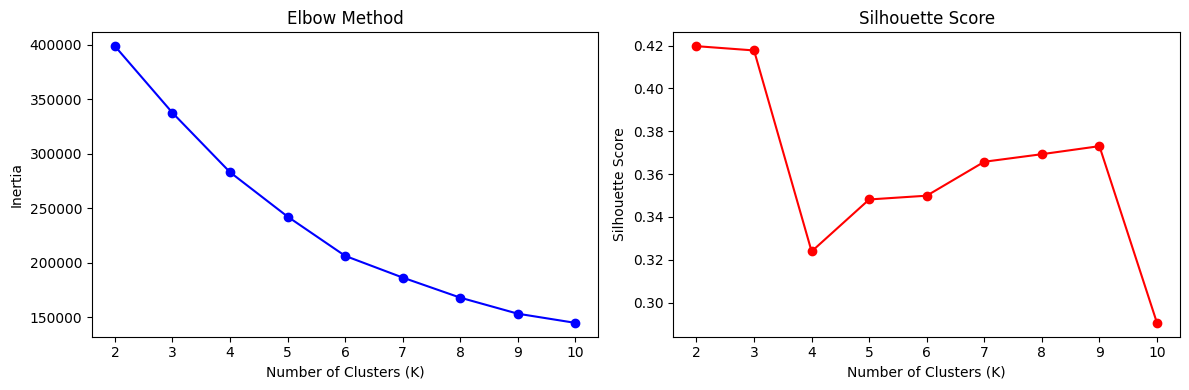

Best K by Silhouette: 2
         recency  frequency  monetary  avg_installments  avg_freight  \
cluster                                                                
0         249.35        1.0    388.38              7.26        32.56   
1         236.65        1.0    134.08              1.80        16.88   
2         238.32        1.0    808.05              4.02        18.29   

         unique_products  
cluster                   
0                   0.99  
1                   0.98  
2                   2.16  
segment
Low-Value Casual       74981
Installment Buyers     18339
High-Value Shoppers     3157
Name: count, dtype: int64
segment
Low-Value Casual       77.7
Installment Buyers     19.0
High-Value Shoppers     3.3
Name: proportion, dtype: float64
                    precision    recall  f1-score   support

Installment Buyers       0.99      0.94      0.97      3668
  Low-Value Casual       0.99      1.00      0.99     14997
High-Value Shopers       1.00      0.99      1.00    

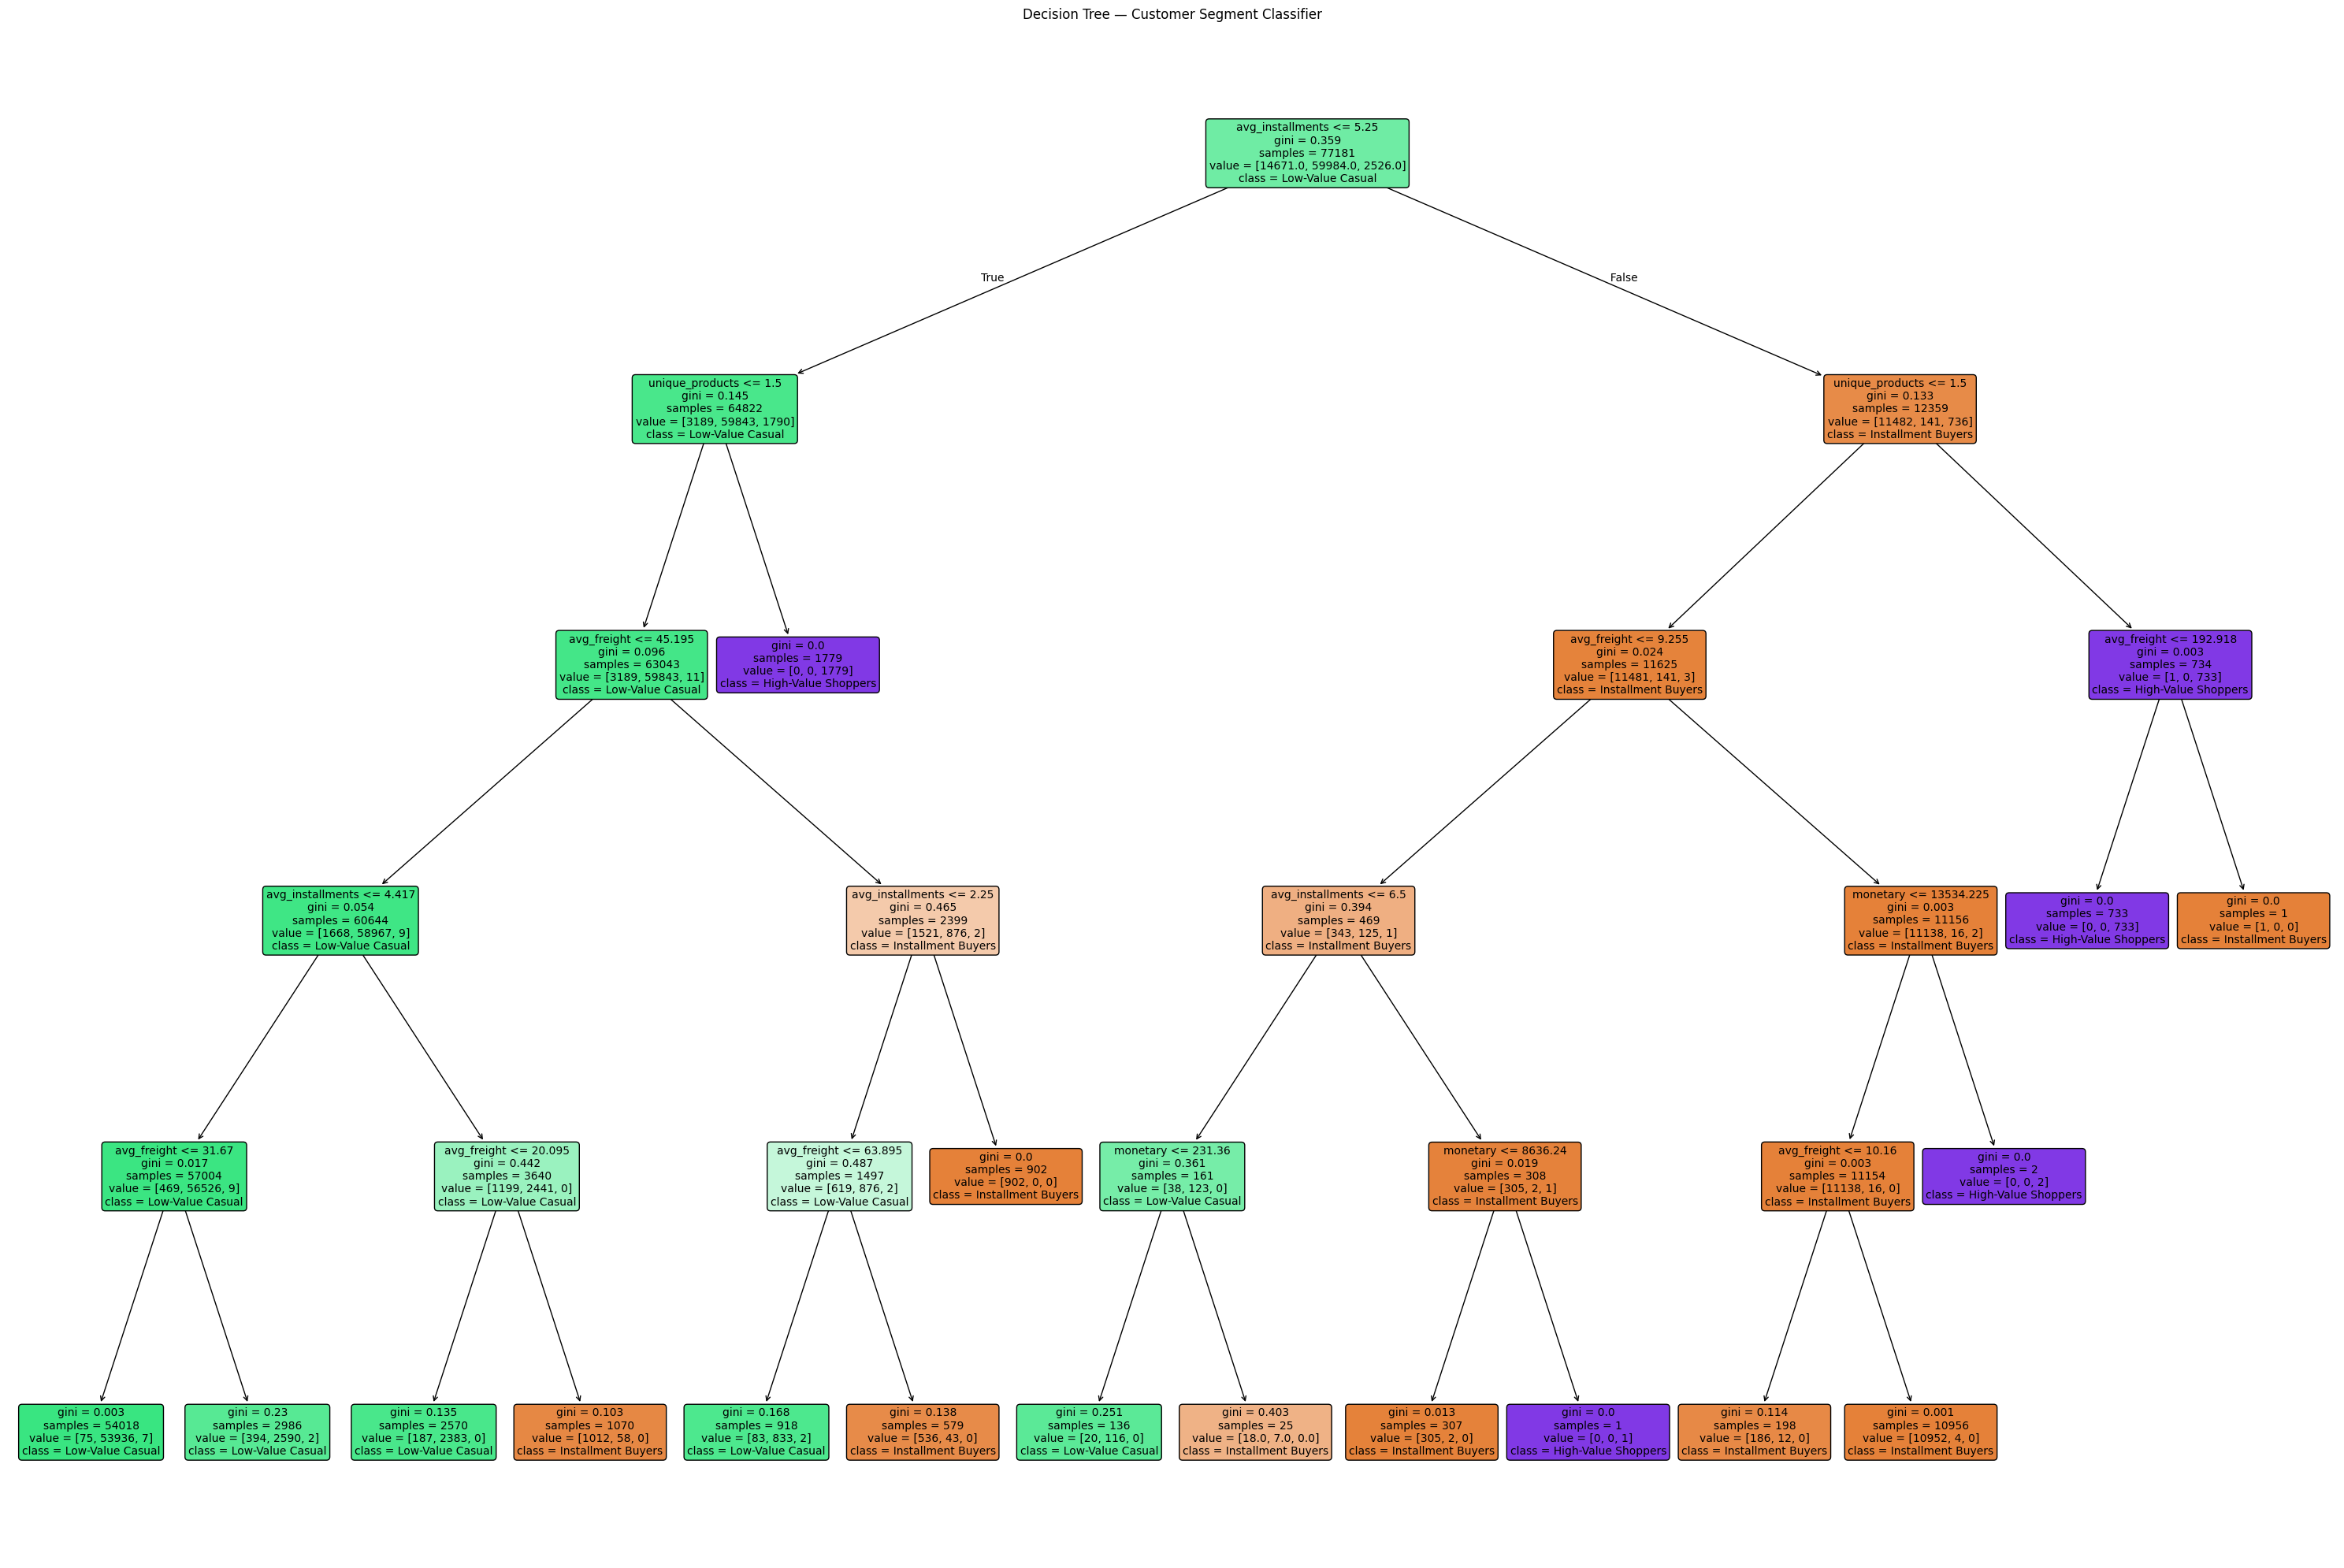

avg_installments    0.686147
unique_products     0.178473
avg_freight         0.134619
monetary            0.000761
frequency           0.000000
recency             0.000000
dtype: float64


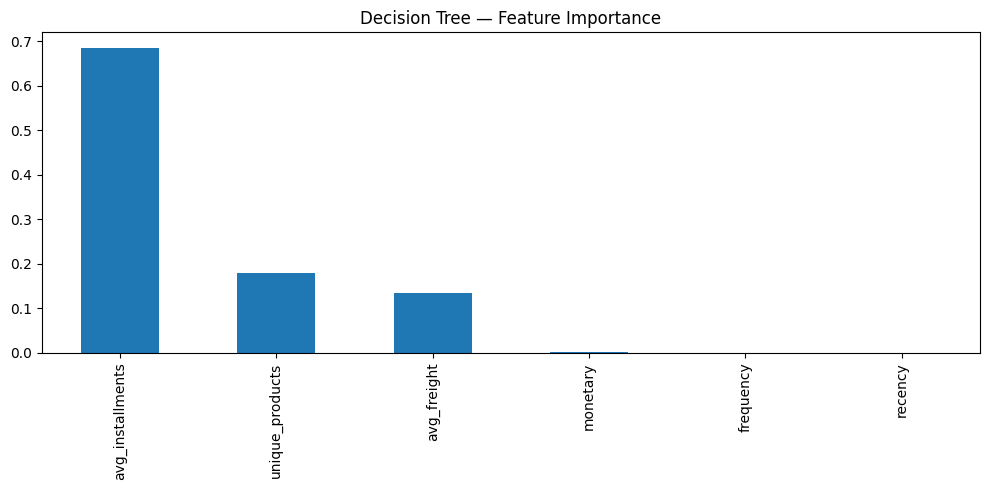

In [61]:
#this is was the first developed mmodel without splitting 90/10 data
X = df[features].copy()
X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to find best K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))


plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.savefig('elbow_plot.png')
plt.show()
print("Best K by Silhouette:", K_range[np.argmax(sil_scores)])

best_k = 3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)
# Profile each cluster
profile = df.groupby('cluster')[features].mean().round(2)
print(profile)

cluster_labels = {
0: 'Installment Buyers',
1: 'Low-Value Casual',
2: 'High-Value Shoppers'
}
df['segment'] = df['cluster'].map(cluster_labels)
print(df['segment'].value_counts())
print(df['segment'].value_counts(normalize=True).mul(100).round(1))

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_cls = df[features].copy()
y_cls = df['cluster']
X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print(classification_report(y_test, dt.predict(X_test),
                            target_names=['Installment Buyers','Low-Value Casual','High-Value Shopers']))

from sklearn.tree import plot_tree
plt.figure(figsize=(30, 20))
plot_tree(
    dt,
    feature_names=features,
    class_names=['Installment Buyers', 'Low-Value Casual', 'High-Value Shoppers'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree — Customer Segment Classifier')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300)
plt.show()

feat_imp = pd.Series(dt.feature_importances_, index=features)
feat_imp = feat_imp.sort_values(ascending=False)
print(feat_imp)
feat_imp.plot(kind='bar', figsize=(10,5), title='Decision Tree — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [62]:
#====================================================
#This is where we checked the model on unseen data.
#Here reecall was dropped to 0 for installment buyer
#====================================================

Train size: 86829 | Test size: 9648


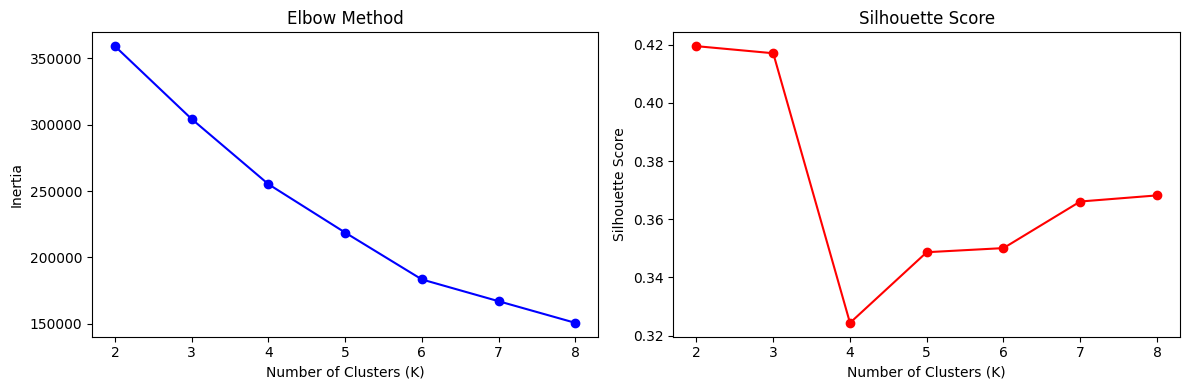


Cluster Profiles:
         recency  frequency  monetary  avg_installments  avg_freight  \
cluster                                                                
0         248.86        1.0    383.79              7.25        32.56   
1         236.82        1.0    134.39              1.80        16.88   
2         237.28        1.0    816.90              4.05        18.38   

         unique_products  
cluster                   
0                   0.99  
1                   0.98  
2                   2.16  

Segment Distribution (train):
segment
Low-Value Casual       67469
Installment Buyers     16509
High-Value Shoppers     2851
Name: count, dtype: int64
segment
Low-Value Casual       77.7
Installment Buyers     19.0
High-Value Shoppers     3.3
Name: proportion, dtype: float64

Cluster Profiles:
         recency  frequency  monetary  avg_installments  avg_freight  \
cluster                                                                
0         248.86        1.0    383.79        

C:\Users\digen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


                     precision    recall  f1-score   support

 Installment Buyers       1.00      0.00      0.00      1837
   Low-Value Casual       0.80      1.00      0.89      7505
High-Value Shoppers       1.00      1.00      1.00       306

           accuracy                           0.81      9648
          macro avg       0.93      0.67      0.63      9648
       weighted avg       0.85      0.81      0.73      9648


Feature Importance:
unique_products     0.500844
avg_installments    0.388042
avg_freight         0.098689
monetary            0.010595
recency             0.001829
frequency           0.000000
dtype: float64


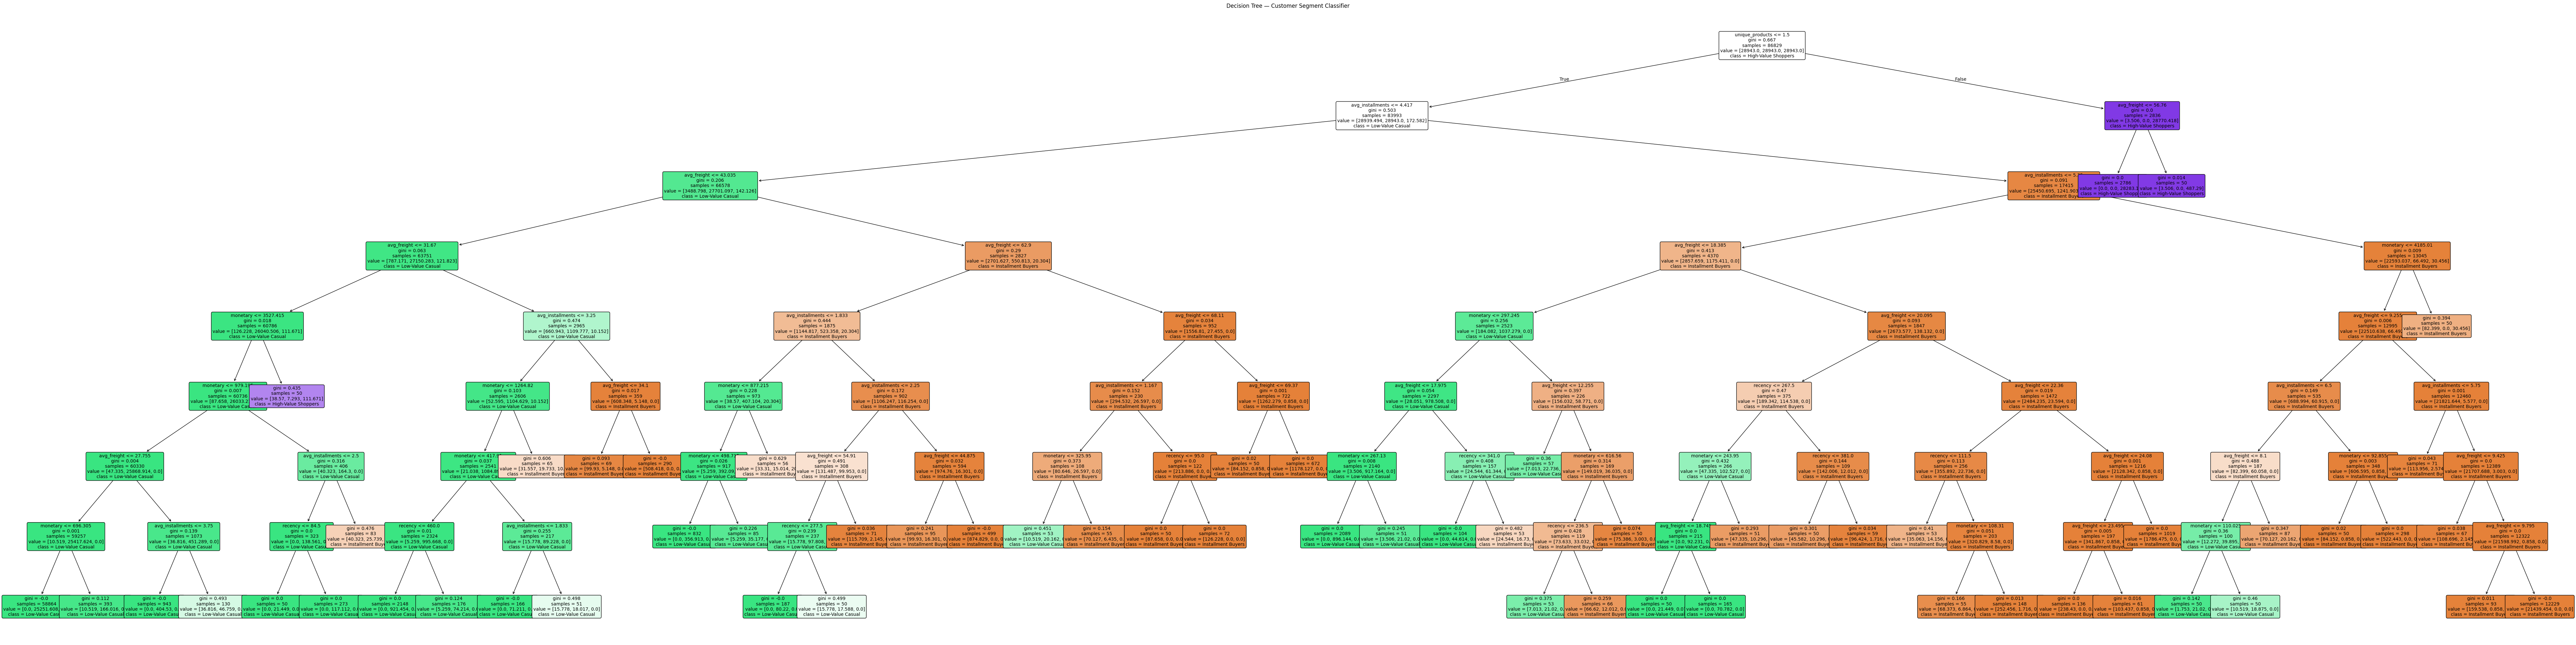


Feature Importance:
unique_products     0.500844
avg_installments    0.388042
avg_freight         0.098689
monetary            0.010595
recency             0.001829
frequency           0.000000
dtype: float64


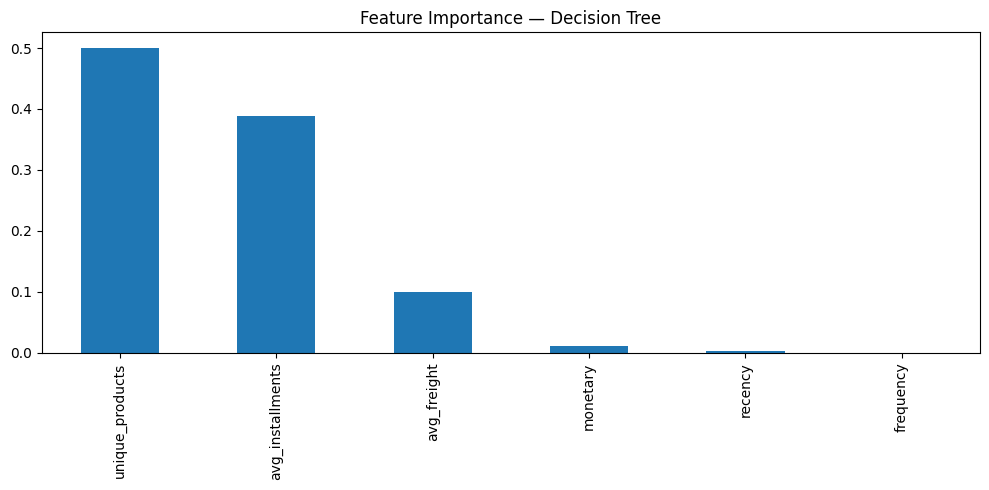

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

features = ['recency','frequency','monetary','avg_installments','avg_freight','unique_products']

# ── Step 1: 90/10 Split BEFORE anything ──────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

# ── Step 2: Scale ONLY on train data ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[features])
X_test_scaled  = scaler.transform(test_df[features])   # transform only, no fit

# ── Step 3: Elbow + Silhouette on train data ──────────────────────────────────
inertia    = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

# ── Step 4: Final K-Means on TRAIN data only ──────────────────────────────────
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_df = train_df.copy()
train_df['cluster'] = km_final.fit_predict(X_train_scaled)

# Cluster profiles
profile = train_df.groupby('cluster')[features].mean().round(2)
print("\nCluster Profiles:")
print(profile)

# Label clusters
cluster_labels = {
    0: 'Installment Buyers',   # highest avg_installments (7.25)
    1: 'Low-Value Casual',     # lowest monetary ($134)
    2: 'High-Value Shoppers'   # highest monetary ($816) + most unique products
}
train_df['segment'] = train_df['cluster'].map(cluster_labels)
print("\nSegment Distribution (train):")
print(train_df['segment'].value_counts())
print(train_df['segment'].value_counts(normalize=True).mul(100).round(1))

# ── Step 4: Final K-Means on TRAIN data only ──────────────────────────────────
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_df = train_df.copy()
train_df['cluster'] = km_final.fit_predict(X_train_scaled)

# Cluster profiles
profile = train_df.groupby('cluster')[features].mean().round(2)
print("\nCluster Profiles:")
print(profile)

# Label clusters
cluster_labels = {
    0: 'Installment Buyers',   # highest avg_installments (7.25)
    1: 'Low-Value Casual',     # lowest monetary ($134)
    2: 'High-Value Shoppers'   # highest monetary ($816) + most unique products
}
train_df['segment'] = train_df['cluster'].map(cluster_labels)
print("\nSegment Distribution (train):")
print(train_df['segment'].value_counts())
print(train_df['segment'].value_counts(normalize=True).mul(100).round(1))

# ── Step 5: Train Decision Tree on 90% clustered data ────────────────────────
X_dt_train = train_df[features]
y_dt_train = train_df['cluster']

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',  
    random_state=42
)
dt.fit(X_dt_train, y_dt_train)

# ── Step 6: Predict clusters on unseen 10% test data ─────────────────────────
y_pred = dt.predict(X_test_scaled)


# Map predicted cluster numbers to labels for report
pred_labels = pd.Series(y_pred).map(cluster_labels)
test_df = test_df.copy()
test_df['predicted_cluster'] = y_pred
test_df['predicted_segment'] = pred_labels

print("=== DECISION TREE EVALUATION ON UNSEEN 10% ===")
print(classification_report(
    km_final.predict(X_test_scaled),
    y_pred,
    target_names=['Installment Buyers', 'Low-Value Casual', 'High-Value Shoppers']
))
# Fix 2: Check what feature splits DT is using
feat_imp = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:")
print(feat_imp)

# ── Step 7: Decision Tree Plot ────────────────────────────────────────────────
plt.figure(figsize=(80, 20))
plot_tree(
    dt,
    feature_names=features,
    class_names=['Installment Buyers', 'Low-Value Casual', 'High-Value Shoppers'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree — Customer Segment Classifier')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=300)
plt.show()

# ── Step 8: Feature Importance ────────────────────────────────────────────────
feat_imp = pd.Series(dt.feature_importances_, index=features)
feat_imp = feat_imp.sort_values(ascending=False)
print("\nFeature Importance:")
print(feat_imp)

feat_imp.plot(kind='bar', figsize=(10,5), 
              title='Feature Importance — Decision Tree')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()